__1. Linear Regression using Boston Housing Dataset__

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

Load the Boston Housing Dataset

In [22]:
# Load Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Display first five rows
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


Separate Features and Target

In [23]:
# Independent Variables
X = df.drop("medv", axis=1)

# Dependent Variable
y = df["medv"]

Split Dataset into Training and Testing

In [24]:
# 80% Training and 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (404, 13)
Testing Set Shape: (102, 13)


Create and train the model andpredict the house price

In [25]:
# Create Model

lr_model = LinearRegression()
# Train Model

lr_model.fit(X_train, y_train)
# Prediction

y_pred = lr_model.predict(X_test)

Evaluate Model

In [26]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 3.1890919658878594
Mean Squared Error : 24.291119474973655
Root Mean Squared Error : 4.92860218266535
R2 Score : 0.6687594935356301


Display Intercept and Coefficients

In [27]:
# Intercept

print("Intercept:")
print(lr_model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, lr_model.coef_):
    print(feature, ":", coef)

Intercept:
30.24675099392328

Coefficients:
crim : -0.1130559239853805
zn : 0.030110464145648195
indus : 0.04038072041333161
chas : 2.784438203507955
nox : -17.202633391781227
rm : 4.438835199513048
age : -0.006296362210977992
dis : -1.4478653685307885
rad : 0.2624297355850912
tax : -0.010646786275308545
ptratio : -0.9154562404680738
b : 0.012351334729969824
lstat : -0.5085714244487907


Compare Actual and Predicted Values

In [28]:
# Actual vs Predicted

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result.head(10))

   Actual Price  Predicted Price
0          23.6        28.996724
1          32.4        36.025565
2          13.6        14.816944
3          22.8        25.031979
4          16.1        18.769880
5          20.0        23.254429
6          17.8        17.662538
7          14.0        14.341190
8          19.6        23.013207
9          16.8        20.632456


__2. Naïve Bayes and Support Vector Machine (SVM) Classification using Sonar Dataset__

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

Load Sonar Dataset

In [30]:
# Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

df = pd.read_csv(url, header=None)

print(df.head())

       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.0032   R  
1  0.0052  0.0044   R  
2  0.0095  0.0078   

Separate Features and Target

In [31]:
# Features
X = df.iloc[:, :-1]
# Target
y = df.iloc[:, -1]

Convert Target Labels into Numbers

In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

Standardize Features

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Split Dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (166, 60)
Testing Set Shape: (42, 60)


Import, Train, Predict and Evaluate Naïve Bayes & SVM

In [35]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)
print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))

# SVM 
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("\nSVM Accuracy:", svm_accuracy)
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))

Naive Bayes Accuracy: 0.6428571428571429

Naive Bayes Confusion Matrix:
[[12 10]
 [ 5 15]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        22
           1       0.60      0.75      0.67        20

    accuracy                           0.64        42
   macro avg       0.65      0.65      0.64        42
weighted avg       0.66      0.64      0.64        42


SVM Accuracy: 0.7619047619047619

SVM Confusion Matrix:
[[19  3]
 [ 7 13]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.86      0.79        22
           1       0.81      0.65      0.72        20

    accuracy                           0.76        42
   macro avg       0.77      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix
print("Naive Bayes Confusion Matrix")
print(confusion_matrix(y_test, nb_pred))
print("\nSVM Confusion Matrix")
print(confusion_matrix(y_test, svm_pred))

Naive Bayes Confusion Matrix
[[12 10]
 [ 5 15]]

SVM Confusion Matrix
[[19  3]
 [ 7 13]]


Classification report

In [37]:
from sklearn.metrics import classification_report
print("Naive Bayes Report")
print(classification_report(y_test, nb_pred))
print("SVM Report")
print(classification_report(y_test, svm_pred))

Naive Bayes Report
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        22
           1       0.60      0.75      0.67        20

    accuracy                           0.64        42
   macro avg       0.65      0.65      0.64        42
weighted avg       0.66      0.64      0.64        42

SVM Report
              precision    recall  f1-score   support

           0       0.73      0.86      0.79        22
           1       0.81      0.65      0.72        20

    accuracy                           0.76        42
   macro avg       0.77      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



Compare both the models

In [38]:
comparison = pd.DataFrame({
    "Classifier":[
        "Naive Bayes",
        "Support Vector Machine"
    ],
    "Accuracy (%)":[
        nb_accuracy*100,
        svm_accuracy*100
    ]
})
print(comparison)

               Classifier  Accuracy (%)
0             Naive Bayes     64.285714
1  Support Vector Machine     76.190476


__3. Evaluation of Linear Regression Model using Learning Curves and Error Metrics__

In [41]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [42]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


Features and Target

In [43]:
X = df.drop("medv", axis=1)
y = df["medv"]

Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (404, 13)
Testing Shape: (102, 13)


Create and train the model and aslo predict

In [45]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

 Evaluate using Error Metrics

In [46]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 3.1890919658878594
Mean Squared Error (MSE): 24.291119474973655
Root Mean Squared Error (RMSE): 4.92860218266535
R2 Score: 0.6687594935356301


Plot Learning Curve

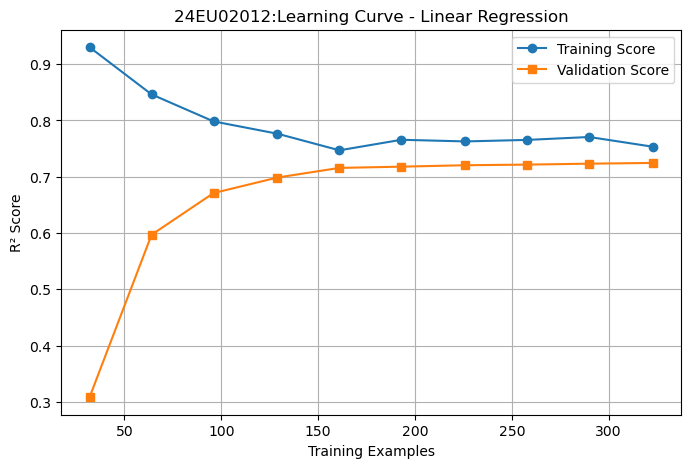

In [47]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=lr_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Score')
plt.title("24EU02012:Learning Curve - Linear Regression")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

Actual vs Predicted Values

In [48]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(result.head(10))

   Actual  Predicted
0    23.6  28.996724
1    32.4  36.025565
2    13.6  14.816944
3    22.8  25.031979
4    16.1  18.769880
5    20.0  23.254429
6    17.8  17.662538
7    14.0  14.341190
8    19.6  23.013207
9    16.8  20.632456
